# Start Trek Results Analysis

This notebook analyses the training and evaluation logs produced for project.  

The analysis focuses on:
- episode rewards,
- episode lengths,
- termination causes,
- run ranking,
- reproducibility across repeated runs,
- evaluation logs after training.


## Imports and configuration


In [411]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

STATUS_COLORS = {
    "Terminated: Crash": "red",
    "Terminated: Landed": "green",
    "Terminated: Out of view": "orange",
    "Truncated: Sleep": "blue",
}

STATUS_SCORE = {
    "Terminated: Crash": -1,
    "Terminated: Landed": 1,
    "Terminated: Out of view": -2,
    "Truncated: Sleep": 0,
}

## Loading training logs

This cell defines functions to read all CSV log files from a directory.  
Each run is stored as a dictionary containing:
- the run configuration extracted from commented header lines,
- the dataframe loaded from the CSV content.

The `get_run_number` function is also used to sort and identify runs based on the number present in the filename.


In [412]:
def load_one_run(file_path):
    file_path = Path(file_path)
    config = {}
    data_lines = []
    with open(file_path, "r") as file:
        for line in file:
            line = line.strip()
            if line == "":
                continue
            if line.startswith("#"):
                clean_line = line.replace("#", "", 1).strip()
                if "," in clean_line:
                    key, value = clean_line.split(",", 1)
                    config[key.strip()] = value.strip()
            else:
                data_lines.append(line)
    if len(data_lines) == 0:
        raise ValueError(f"no data found in {file_path}")
    df = pd.read_csv(file_path, comment="#")
    df["Run_file"] = file_path.name
    return config, df

def get_run_number(file_path):
    name = file_path.name
    parts = name.split("_")
    try:
        return int(parts[1])
    except:
        return parts[1]

def load_all_runs(logs_dir="logs"):
    logs_dir = Path(logs_dir)
    if not logs_dir.exists():
        raise FileNotFoundError(f"dir {logs_dir} does not exist")
    csv_files = sorted(logs_dir.glob("*.csv"), key=get_run_number)
    print(csv_files)
    if len(csv_files) == 0:
        raise FileNotFoundError(f"no csv found in {logs_dir}")
    runs = {}
    for file_path in csv_files:
        config, df = load_one_run(file_path)
        runs[file_path.name] = {"config": config, "data": df}
    return runs

## Inspecting the loaded data

This cell loads the training logs and displays the first run.  
The purpose is to quickly verify that the CSV files were loaded correctly and that the expected columns are present, such as `Episode`, `Reward`, `Episode_length`, and `Status`.


In [413]:
runs = load_all_runs("../../src/train/logs")

for run_name, run in list(runs.items())[:1]:
    print(run_name)
    display(run["config"])
    display(run["data"])

[PosixPath('../../src/train/logs/run_10_2026-05-06_12h10m42s.csv'), PosixPath('../../src/train/logs/run_10_2026-05-06_14h54m14s.csv'), PosixPath('../../src/train/logs/run_30_2026-04-28_09h23m06s.csv'), PosixPath('../../src/train/logs/run_50_2026-05-05_12h36m34s.csv'), PosixPath('../../src/train/logs/run_100_2026-04-27_21h49m47s.csv'), PosixPath('../../src/train/logs/run_200_2026-05-06_12h31m16s.csv'), PosixPath('../../src/train/logs/run_300_2026-04-27_21h56m58s.csv'), PosixPath('../../src/train/logs/run_400_2026-05-06_12h20m19s.csv'), PosixPath('../../src/train/logs/run_500_2026-04-27_22h08m50s.csv'), PosixPath('../../src/train/logs/run_600_2026-05-11_14h45m39s.csv'), PosixPath('../../src/train/logs/run_600_2026-05-11_14h55m13s.csv'), PosixPath('../../src/train/logs/run_600_2026-05-11_15h20m34s.csv'), PosixPath('../../src/train/logs/run_600_2026-05-11_14h36m04s.csv'), PosixPath('../../src/train/logs/run_600_2026-04-28_09h36m23s.csv'), PosixPath('../../src/train/logs/run_700_2026-05-06_

{'Environment': 'LunarLander-v3',
 'Render mode': 'rgb_array',
 'Batch': '128',
 'Gamma': '0.99',
 'Eps_start': '0.9',
 'Eps_end': '0.01',
 'Eps_decay': '2500',
 'Tau': '0.005',
 'Lr': '0.0003'}

,Episode,Reward,Episode_length,Status,Run_file
0,0,-258.849892,93,Terminated: Crash,run_10_2026-05-06_12h10m42s.csv
1,1,-259.915943,95,Terminated: Crash,run_10_2026-05-06_12h10m42s.csv
2,2,-107.180915,80,Terminated: Crash,run_10_2026-05-06_12h10m42s.csv
3,3,-134.330191,70,Terminated: Crash,run_10_2026-05-06_12h10m42s.csv
4,4,-63.407527,96,Terminated: Crash,run_10_2026-05-06_12h10m42s.csv
5,5,-58.365832,75,Terminated: Crash,run_10_2026-05-06_12h10m42s.csv
6,6,-108.005709,74,Terminated: Crash,run_10_2026-05-06_12h10m42s.csv
7,7,-78.266650,139,Terminated: Crash,run_10_2026-05-06_12h10m42s.csv
8,8,1.013501,205,Terminated: Crash,run_10_2026-05-06_12h10m42s.csv
9,9,-71.548239,80,Terminated: Crash,run_10_2026-05-06_12h10m42s.csv


## Reward graph for each runs

This function show the reward progression for all runs.  
A rolling mean is applied to reduce noise and make the graph easier to read.

The optional `mean` argument allows the average curve to be highlighted in red while the individual runs are shown in blue.  
The optional `last_100` argument focuses the graph on the final 100 episodes, because the project is based on the mean score over 100 consecutive episodes.


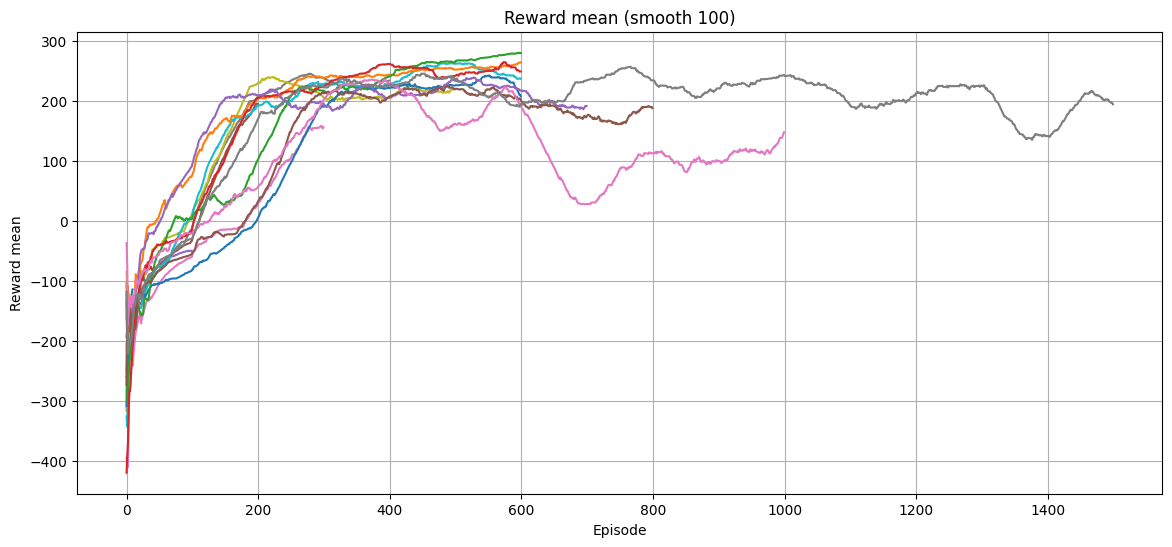

In [414]:
def all_rewards(runs, mean = False, last_100 = False, smooth=100):
    plt.figure(figsize=(14, 6))

    for run_name, run in runs.items():
        df = run["data"].copy()
        df = df.sort_values("Episode")
        if last_100:
            df = df.tail(100)
        df["Smooth_reward"] = df["Reward"].rolling(window=smooth, min_periods=1).mean()
        if mean:
            if run_name == "mean":
                plt.plot(df["Episode"], df["Smooth_reward"], label="mean", color="red")
            else:
                plt.plot(df["Episode"], df["Smooth_reward"], label=run_name, color="blue")
        else:
            plt.plot(df["Episode"], df["Smooth_reward"], label=run_name)

    plt.xlabel("Episode")
    plt.ylabel("Reward mean")
    plt.title(f"Reward mean (smooth {smooth})" + (" for 100 lasts episode" if last_100 else "") + (" + mean of all" if mean else ""))
    plt.grid(True)
    plt.show()

all_rewards(runs)

This graph is used to evaluate how the models learns over time.  
A successful training process should show rewards increasing and stabilizing above the target score.  
If the last 100 episodes are consistently above 200, the models is good.


## Episode length graph

This function show the smoothed episode length for each run.  


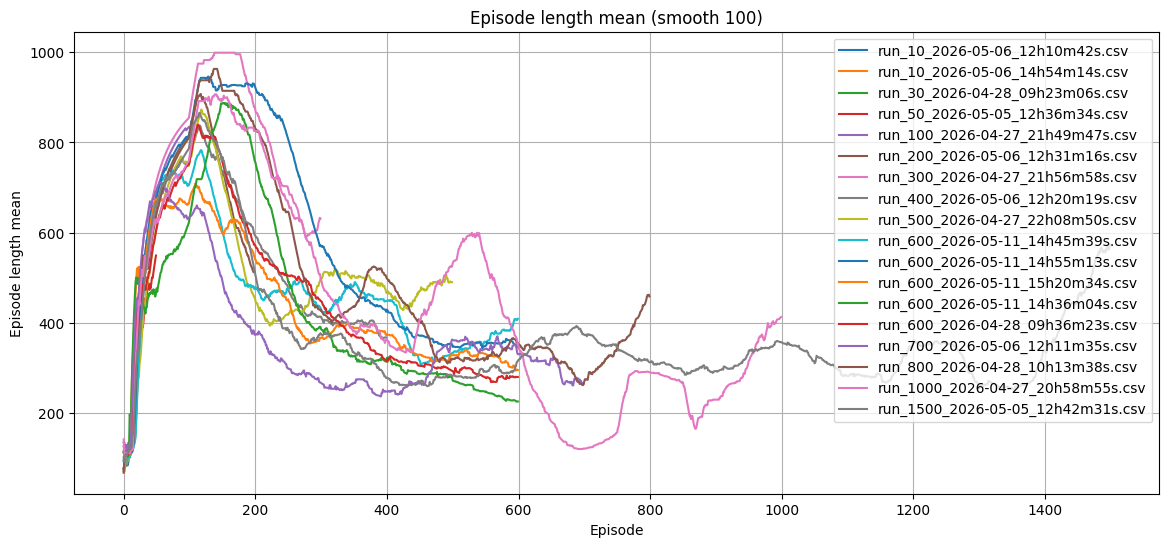

In [415]:
def all_episode_lengths(runs, smooth=100):
    plt.figure(figsize=(14, 6))

    for run_name, run in runs.items():
        df = run["data"].copy()
        df = df.sort_values("Episode")
        df["Smooth_episode_length"] = df["Episode_length"].rolling(window=smooth, min_periods=1).mean()
        plt.plot(df["Episode"], df["Smooth_episode_length"], label=run_name)

    plt.title(f"Episode length mean (smooth {smooth})")
    plt.xlabel("Episode")
    plt.ylabel("Episode length mean")
    plt.legend()
    plt.grid(True)
    plt.show()

all_episode_lengths(runs)

This plot complements the reward graph.


## Termination status distribution

This function counts how each episode ended for every run and displays the result as a stacked bar chart.  
The statuses help distinguish successful landings from crashes, out-of-view failures, and truncations caused by sleep or time limits.


In [416]:
def all_status_distribution(runs, percentage=False):
    rows = []
    for run_name, run in runs.items():
        df = run["data"].copy()
        for status, count in df["Status"].value_counts().items():
            rows.append({"Run": run_name, "Status": status, "Count": count})
    status_df = pd.DataFrame(rows)
    pivot_df = status_df.pivot(index="Run", columns="Status", values="Count").fillna(0)
    pivot_df = pivot_df.loc[list(runs.keys())]
    if percentage:
        pivot_df = pivot_df.div(pivot_df.sum(axis=1), axis=0) * 100
    colors = [STATUS_COLORS.get(status, "black") for status in pivot_df.columns]
    ax = pivot_df.plot(kind="bar", stacked=True, figsize=(14, 6), color=colors)
    ax.set_xticklabels([f"{get_run_number(Path(run_name))}" for run_name in pivot_df.index],rotation=0)
    plt.title("Statuts by run" + (" (%)" if percentage else ""))
    if percentage:
        plt.legend("", frameon=False)
        plt.ylabel("Percentage")
    else:
        plt.legend(title="Status")
        plt.ylabel("Count")
    plt.xlabel("episode number")
    plt.show()

Termination status by run classic and by percentage

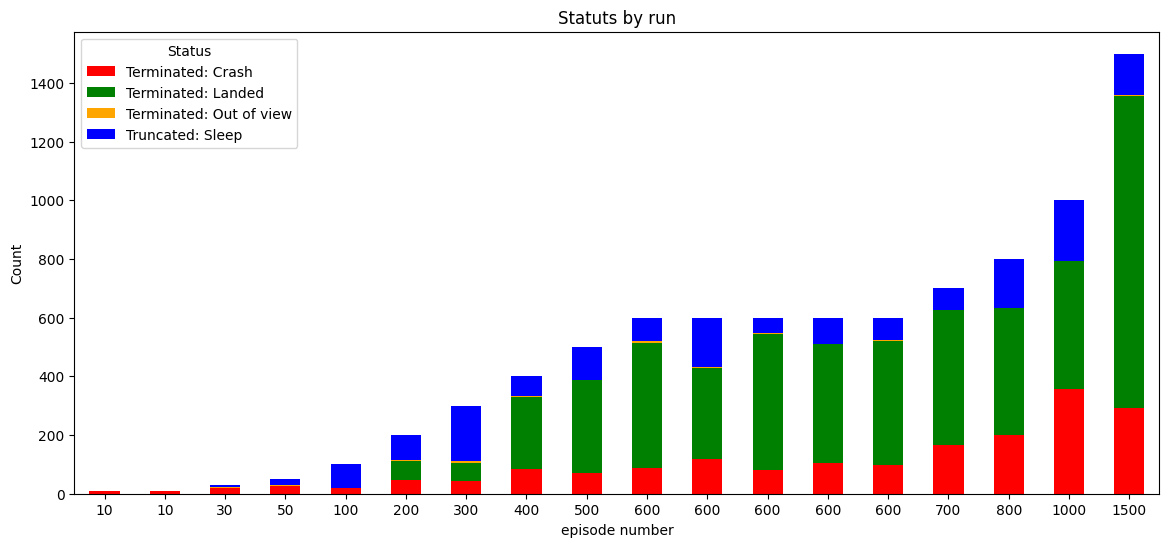

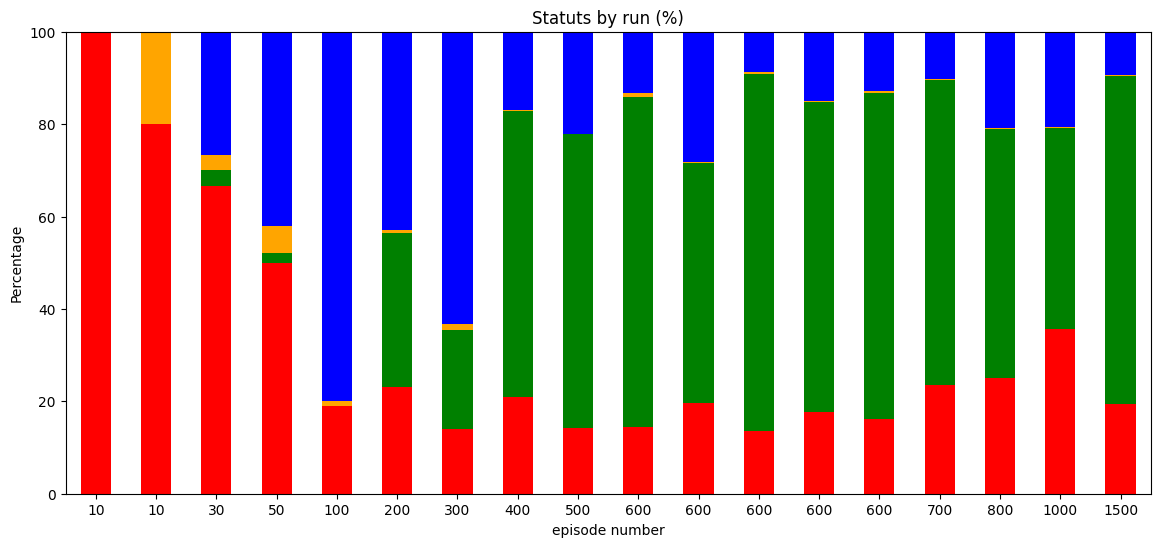

In [417]:
all_status_distribution(runs)
all_status_distribution(runs, True)

The percentage view is better for comparing multiple runs with differents episodes numbers.  
Here the best episodes choice seem to be ~600.


## Run ranking based on termination

This cell assigns a simple score to each run based on its termination status.
Successful landings receive a positive weight, while crashes and out-of-view failures receive negative weights.

In [418]:
def compute_run_scores(runs):
    rows = []
    for run_name, run in runs.items():
        df = run["data"].copy()
        counts = df["Status"].value_counts()
        total = counts.sum()
        score = 0
        for status, count in counts.items():
            weight = STATUS_SCORE.get(status, 0)
            score += (count / total) * weight
        score_round = round(score, 2)
        rows.append({"Run (episode number)": get_run_number(Path(run_name)), "Score": score_round})
    score_df = pd.DataFrame(rows)
    return score_df.sort_values("Score", ascending=False)

ranking = compute_run_scores(runs)
print(ranking.to_string(index=False))


 Run (episode number)  Score
                  600   0.63
                  600   0.55
                  600   0.53
                 1500   0.51
                  600   0.49
                  500   0.49
                  700   0.42
                  400   0.40
                  600   0.32
                  800   0.28
                  200   0.10
                 1000   0.08
                  300   0.05
                  100  -0.21
                   50  -0.60
                   30  -0.70
                   10  -1.00
                   10  -1.20


The ranking helps identify which runs produced the best results, here it is 600.


## Reproducibility analysis for 600 episode runs

This cell filters the logs to keep only the runs with 600 episodes (with different seeds).  
It then computes an episode by episode average reward to create a new `mean` run.


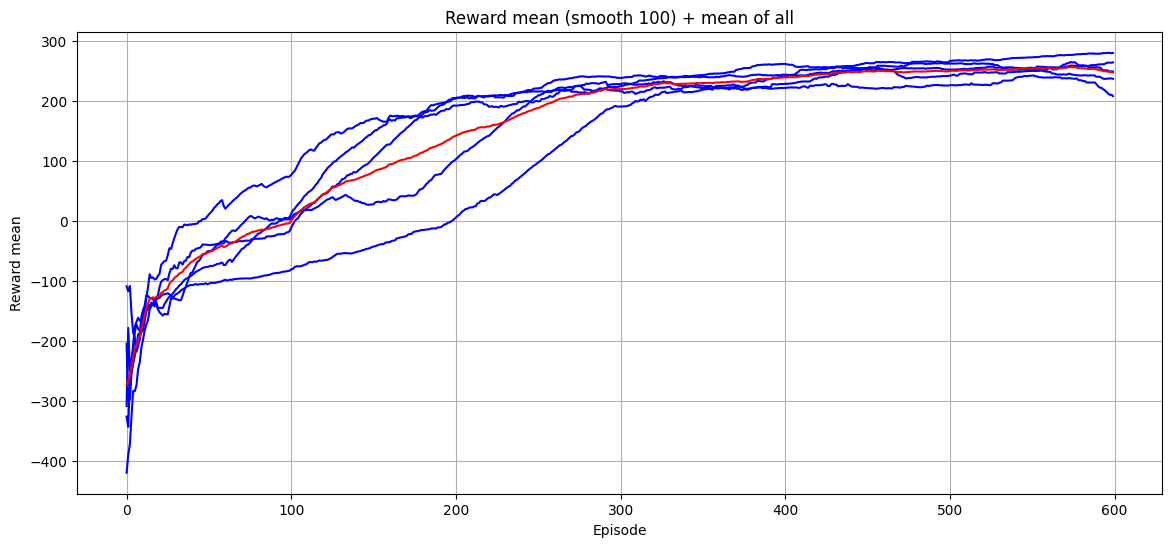

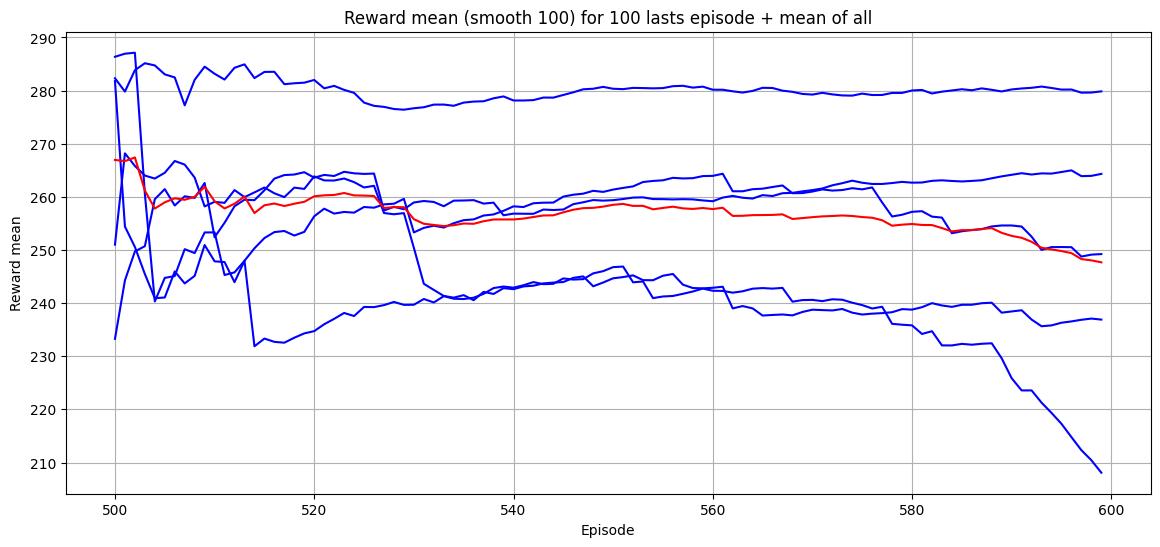

In [419]:
runs_600_episodes = {}

for run_name, run in runs.items():
    if (get_run_number(Path(run_name)) != 600):
        continue
    runs_600_episodes[run_name] = run

new_colone = []

for i in range(600):
    reward_total = 0
    reward_mean = 0
    for run in runs_600_episodes.values():
        df = run["data"]
        reward_total += float(df["Reward"].iloc[i])
    reward_mean = reward_total / len(runs_600_episodes)
    new_colone.append({"Episode": i, "Reward": reward_mean})

runs_600_episodes["mean"] = {"data": pd.DataFrame(new_colone)}

all_rewards(runs_600_episodes, True)
all_rewards(runs_600_episodes, True, True)

The first graph gives an overview of training progression, while the last 100 episodes graph focuses on final performance.  
Here we can see that for the 100 last episode the mean is above 200, and the mean of all is alwayse above 240.


## Evaluation logs

This cell loads and display graph for the evaluation logs.


[PosixPath('../../src/eval/logs/run_default_eval_2026-05-15_18h35m45s.csv'), PosixPath('../../src/eval/logs/run_earth_eval_2026-05-15_18h32m52s.csv'), PosixPath('../../src/eval/logs/run_moon_eval_2026-05-12_10h40m06s.csv')]


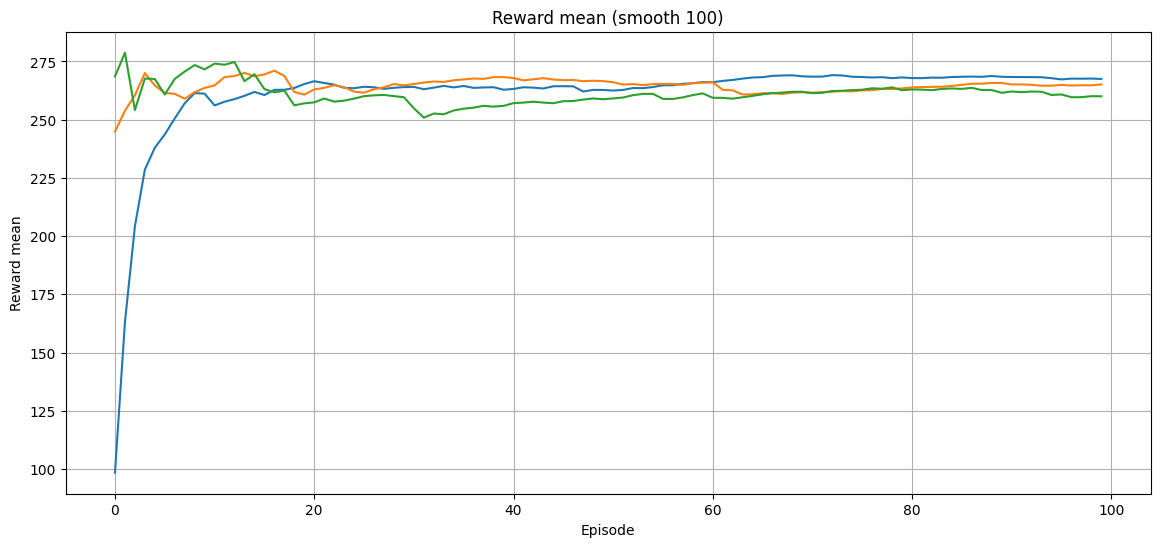

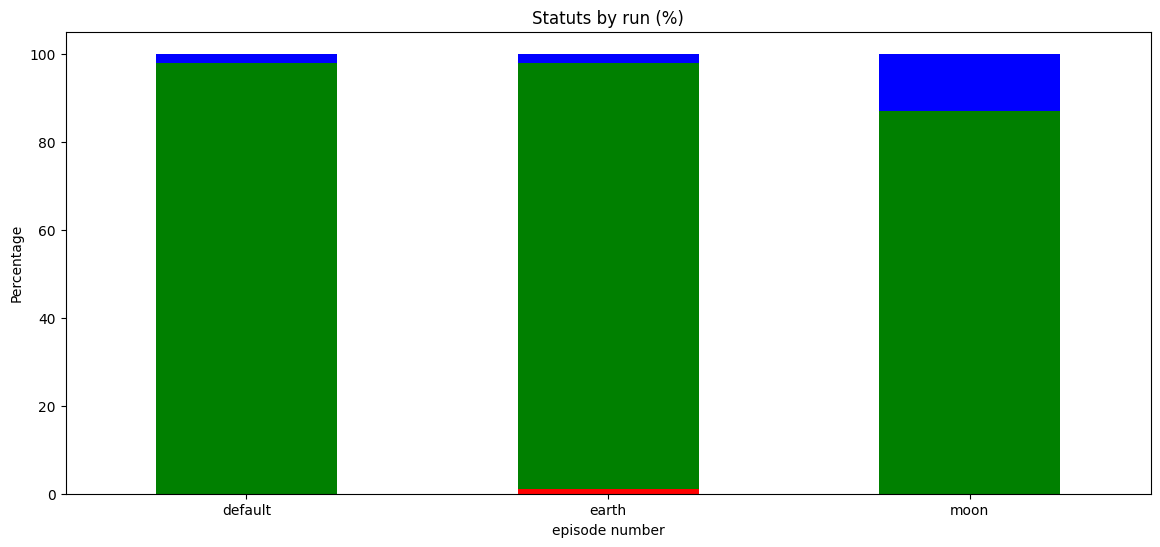

In [420]:
runs = load_all_runs("../../src/eval/logs")
all_rewards(runs)
all_status_distribution(runs, True)

The evaluation graph confirm that the trained model performs consistently for 100 consecutive episodes.
